# Fine Tuning - Vision Transformer (ViT)

---


Brain Tumor MRI Classification

## Dependencias

In [1]:
%pip install -q transformers==5.0.0 timm scikit-learn matplotlib seaborn tqdm pillow

## Imports

In [2]:
import os, json, random, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from transformers import AutoImageProcessor, AutoModelForImageClassification

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Semilla global
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.cuda.manual_seed_all(SEMILLA)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo activo : {DEVICE}")

Dispositivo activo : cuda


## Montar Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DIR_PROYECTO = Path('/content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri')
RUTA_CONFIG  = DIR_PROYECTO / 'dataset_config.json'

with open(RUTA_CONFIG, encoding='utf-8') as f:
    CFG = json.load(f)

DIR_SPLITS = Path(CFG['dir_splits'])
CLASES     = CFG['clases']          # ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE   = CFG['img_size']        # 224
MEDIA      = CFG['media_norm']
DESV       = CFG['desv_norm']
CLASE2IDX  = {c: i for i, c in enumerate(CLASES)}
IDX2CLASE  = {i: c for c, i in CLASE2IDX.items()}
N_CLASES   = len(CLASES)

print(f"Splits  : {DIR_SPLITS}")
print(f"Clases  : {CLASES}")
print(f"Conteo  :")
for split, conteo in CFG['conteo_splits'].items():
    print(f"  {split:<6} → {sum(conteo.values())} imagenes  {dict(conteo)}")


Mounted at /content/drive
Splits  : /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/brain_tumor_splits
Clases  : ['glioma', 'meningioma', 'notumor', 'pituitary']
Conteo  :
  train  → 1120 imagenes  {'glioma': 280, 'meningioma': 280, 'notumor': 280, 'pituitary': 280}
  val    → 240 imagenes  {'glioma': 60, 'meningioma': 60, 'notumor': 60, 'pituitary': 60}
  test   → 240 imagenes  {'glioma': 60, 'meningioma': 60, 'notumor': 60, 'pituitary': 60}


## Dataset y Dataloaders

In [5]:
class TumorMRIDataset(Dataset):
    """Dataset de imagenes MRI de tumores cerebrales.

    Carga imagenes desde subdirectorios por clase y aplica
    las transformaciones indicadas.
    """

    EXTENSIONES = {'.jpg', '.jpeg', '.png', '.bmp'}

    def __init__(self, directorio: Path, transformaciones=None):
        self.transformaciones = transformaciones
        self.muestras = []  # (ruta, idx_clase)

        for clase in CLASES:
            dir_clase = directorio / clase
            if not dir_clase.exists():
                raise FileNotFoundError(f"No se encontro: {dir_clase}")
            for ruta in dir_clase.rglob('*'):
                if ruta.suffix.lower() in self.EXTENSIONES:
                    self.muestras.append((ruta, CLASE2IDX[clase]))

        random.shuffle(self.muestras)

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, idx):
        ruta, etiqueta = self.muestras[idx]
        img = Image.open(ruta).convert('RGB')
        if self.transformaciones:
            img = self.transformaciones(img)
        return img, etiqueta


# Transformaciones
transform_train = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=MEDIA, std=DESV),
])

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEDIA, std=DESV),
])

ds_train = TumorMRIDataset(DIR_SPLITS / 'train', transform_train)
ds_val   = TumorMRIDataset(DIR_SPLITS / 'val',   transform_eval)
ds_test  = TumorMRIDataset(DIR_SPLITS / 'test',  transform_eval)

print(f"Muestras train: {len(ds_train)}  val: {len(ds_val)}  test: {len(ds_test)}")


Muestras train: 1120  val: 240  test: 240


## Espacio de Búsuqeda de Hiperparámetros

In [6]:
# Espacio de busqueda
ESPACIO_HP = {
    'lr'          : [1e-5, 5e-5, 1e-4, 3e-4],
    'batch_size'  : [16],
    'dropout'     : [0.0, 0.1, 0.3],
    'scheduler'   : ['cosine', 'step'],
}

N_ENSAYOS       = 4    # configuraciones a evaluar
EPOCAS_MAX      = 30
PACIENCIA_ES    = 5    # early stopping: epocas sin mejora en F1-val

# Muestrar configuraciones que se evaluaran
random.seed(SEMILLA)
ensayos = []
for i in range(N_ENSAYOS):
    cfg_ensayo = {k: random.choice(v) for k, v in ESPACIO_HP.items()}
    cfg_ensayo['id'] = i + 1
    ensayos.append(cfg_ensayo)

print("Configuraciones a evaluar:")
for e in ensayos:
    print(f"  Ensayo {e['id']}: lr={e['lr']:.0e}  batch={e['batch_size']}"
          f"  dropout={e['dropout']}  scheduler={e['scheduler']}")


Configuraciones a evaluar:
  Ensayo 1: lr=1e-05  batch=16  dropout=0.3  scheduler=step
  Ensayo 2: lr=5e-05  batch=16  dropout=0.0  scheduler=cosine
  Ensayo 3: lr=1e-05  batch=16  dropout=0.0  scheduler=cosine
  Ensayo 4: lr=1e-05  batch=16  dropout=0.0  scheduler=cosine


## Funciones auxiliares de entrenamiento

In [7]:
def construir_modelo(dropout: float) -> nn.Module:
    """Carga ViT-Base preentrenado y reemplaza la cabeza clasificadora."""
    modelo = AutoModelForImageClassification.from_pretrained(
        'google/vit-base-patch16-224',
        num_labels=N_CLASES,
        ignore_mismatched_sizes=True,
        attn_implementation="eager"
    )
    # Reemplazar la cabeza con dropout opcional
    dim_entrada = modelo.classifier.in_features
    if dropout > 0:
        modelo.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(dim_entrada, N_CLASES)
        )
    else:
        modelo.classifier = nn.Linear(dim_entrada, N_CLASES)
    return modelo.to(DEVICE)


def construir_scheduler(optimizador, tipo: str, epocas: int):
    """Construye el scheduler de tasa de aprendizaje."""
    if tipo == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=epocas, eta_min=1e-7)
    else:  # step
        return optim.lr_scheduler.StepLR(optimizador, step_size=10, gamma=0.1)


def calcular_metricas(etiquetas_reales, predicciones, probabilidades=None):
    """Calcula el conjunto completo de metricas de evaluacion."""
    metricas = {
        'accuracy'   : accuracy_score(etiquetas_reales, predicciones),
        'f1_macro'   : f1_score(etiquetas_reales, predicciones, average='macro', zero_division=0),
        'precision'  : precision_score(etiquetas_reales, predicciones, average='macro', zero_division=0),
        'recall'     : recall_score(etiquetas_reales, predicciones, average='macro', zero_division=0),
        'f1_clases'  : f1_score(etiquetas_reales, predicciones, average=None, zero_division=0).tolist(),
    }
    if probabilidades is not None:
        try:
            metricas['auc_roc'] = roc_auc_score(
                etiquetas_reales, probabilidades,
                multi_class='ovr', average='macro'
            )
        except Exception:
            metricas['auc_roc'] = None
    return metricas


def evaluar(modelo, loader):
    """Evalua el modelo sobre un DataLoader y devuelve metricas."""
    modelo.eval()
    todas_etiq, todos_pred, todas_prob = [], [], []

    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes = imagenes.to(DEVICE)
            salidas  = modelo(imagenes)
            logits   = salidas.logits if hasattr(salidas, 'logits') else salidas
            probs    = torch.softmax(logits, dim=1).cpu().numpy()
            preds    = logits.argmax(dim=1).cpu().numpy()

            todas_etiq.extend(etiquetas.numpy())
            todos_pred.extend(preds)
            todas_prob.extend(probs)

    return (np.array(todas_etiq), np.array(todos_pred),
            np.array(todas_prob),
            calcular_metricas(todas_etiq, todos_pred, np.array(todas_prob)))


## Entrenamiento con ensayo

In [8]:
def entrenar_ensayo(config: dict, verbose: bool = True):
    """Entrena el modelo con una configuracion de hiperparametros.

    Retorna el mejor estado del modelo (por F1-macro val) y el
    historial completo de metricas por epoca.
    """
    loader_train = DataLoader(
        ds_train, batch_size=config['batch_size'],
        shuffle=True, num_workers=2, pin_memory=True
    )
    loader_val = DataLoader(
        ds_val, batch_size=config['batch_size'],
        shuffle=False, num_workers=2, pin_memory=True
    )

    modelo    = construir_modelo(config['dropout'])
    criterio  = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(modelo.parameters(), lr=config['lr'], weight_decay=1e-4)
    scheduler = construir_scheduler(optimizer, config['scheduler'], EPOCAS_MAX)

    historial = {
        'loss_train': [], 'loss_val': [],
        'f1_train'  : [], 'f1_val'  : [],
        'acc_train' : [], 'acc_val' : [],
    }

    mejor_f1_val    = 0.0
    mejor_estado    = None
    epocas_sin_mejora = 0
    tiempo_inicio   = time.time()

    for epoca in range(1, EPOCAS_MAX + 1):
        # Entrenamiento
        modelo.train()
        loss_total, todas_etiq_t, todos_pred_t = 0.0, [], []

        for imagenes, etiquetas in loader_train:
            imagenes, etiquetas = imagenes.to(DEVICE), etiquetas.to(DEVICE)
            optimizer.zero_grad()
            salidas = modelo(imagenes)
            logits  = salidas.logits if hasattr(salidas, 'logits') else salidas
            loss    = criterio(logits, etiquetas)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizer.step()

            loss_total += loss.item() * imagenes.size(0)
            todos_pred_t.extend(logits.argmax(1).cpu().numpy())
            todas_etiq_t.extend(etiquetas.cpu().numpy())

        scheduler.step()
        loss_train_ep = loss_total / len(ds_train)
        f1_train_ep   = f1_score(todas_etiq_t, todos_pred_t, average='macro', zero_division=0)
        acc_train_ep  = accuracy_score(todas_etiq_t, todos_pred_t)

        # Validacion
        modelo.eval()
        loss_val_total, todas_etiq_v, todos_pred_v = 0.0, [], []
        with torch.no_grad():
            for imagenes, etiquetas in loader_val:
                imagenes, etiquetas = imagenes.to(DEVICE), etiquetas.to(DEVICE)
                salidas = modelo(imagenes)
                logits  = salidas.logits if hasattr(salidas, 'logits') else salidas
                loss_val_total += criterio(logits, etiquetas).item() * imagenes.size(0)
                todos_pred_v.extend(logits.argmax(1).cpu().numpy())
                todas_etiq_v.extend(etiquetas.cpu().numpy())

        loss_val_ep = loss_val_total / len(ds_val)
        f1_val_ep   = f1_score(todas_etiq_v, todos_pred_v, average='macro', zero_division=0)
        acc_val_ep  = accuracy_score(todas_etiq_v, todos_pred_v)

        # Historial
        historial['loss_train'].append(loss_train_ep)
        historial['loss_val'].append(loss_val_ep)
        historial['f1_train'].append(f1_train_ep)
        historial['f1_val'].append(f1_val_ep)
        historial['acc_train'].append(acc_train_ep)
        historial['acc_val'].append(acc_val_ep)

        if verbose:
            print(f"  Epoca {epoca:>2}/{EPOCAS_MAX} | "
                  f"loss_train={loss_train_ep:.4f}  loss_val={loss_val_ep:.4f} | "
                  f"f1_train={f1_train_ep:.4f}  f1_val={f1_val_ep:.4f}")

        # Early stopping
        if f1_val_ep > mejor_f1_val + 1e-4:
            mejor_f1_val      = f1_val_ep
            mejor_estado      = deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= PACIENCIA_ES:
                if verbose:
                    print(f"  Early stopping en epoca {epoca} (sin mejora en {PACIENCIA_ES} epocas).")
                break

    tiempo_total = time.time() - tiempo_inicio
    return mejor_estado, historial, mejor_f1_val, tiempo_total


## Búsuqeda aleatoria de Hiperparámetros


In [9]:
resultados_ensayos = []

for ensayo in ensayos:
    print(f"\n{'='*60}")
    print(f"ENSAYO {ensayo['id']}/{N_ENSAYOS}  |  "
          f"lr={ensayo['lr']:.0e}  dropout={ensayo['dropout']}  "
          f"scheduler={ensayo['scheduler']}")
    print('='*60)

    mejor_estado, historial, mejor_f1, tiempo = entrenar_ensayo(ensayo)

    resultados_ensayos.append({
        'id'          : ensayo['id'],
        'config'      : ensayo,
        'mejor_estado': mejor_estado,
        'historial'   : historial,
        'mejor_f1_val': mejor_f1,
        'tiempo_seg'  : round(tiempo, 1),
    })
    print(f"  Mejor F1-val: {mejor_f1:.4f}  |  Tiempo: {tiempo/60:.1f} min")

# Seleccionar mejor ensayo
mejor_ensayo = max(resultados_ensayos, key=lambda x: x['mejor_f1_val'])
print(f"\n{'='*60}")
print(f"Mejor ensayo: #{mejor_ensayo['id']}  |  F1-val={mejor_ensayo['mejor_f1_val']:.4f}")
print(f"Configuracion: {mejor_ensayo['config']}")



ENSAYO 1/4  |  lr=1e-05  dropout=0.3  scheduler=step


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoca  1/30 | loss_train=0.9087  loss_val=0.5860 | f1_train=0.6484  f1_val=0.8350
  Epoca  2/30 | loss_train=0.4608  loss_val=0.4041 | f1_train=0.8433  f1_val=0.8620
  Epoca  3/30 | loss_train=0.3118  loss_val=0.2879 | f1_train=0.8886  f1_val=0.9078
  Epoca  4/30 | loss_train=0.2087  loss_val=0.2184 | f1_train=0.9303  f1_val=0.9338
  Epoca  5/30 | loss_train=0.1469  loss_val=0.1910 | f1_train=0.9456  f1_val=0.9377
  Epoca  6/30 | loss_train=0.1063  loss_val=0.1722 | f1_train=0.9679  f1_val=0.9460
  Epoca  7/30 | loss_train=0.0789  loss_val=0.1849 | f1_train=0.9759  f1_val=0.9421
  Epoca  8/30 | loss_train=0.0671  loss_val=0.1549 | f1_train=0.9830  f1_val=0.9504
  Epoca  9/30 | loss_train=0.0476  loss_val=0.1877 | f1_train=0.9866  f1_val=0.9501
  Epoca 10/30 | loss_train=0.0321  loss_val=0.2035 | f1_train=0.9902  f1_val=0.9418
  Epoca 11/30 | loss_train=0.0253  loss_val=0.1553 | f1_train=0.9920  f1_val=0.9585
  Epoca 12/30 | loss_train=0.0310  loss_val=0.1627 | f1_train=0.9902  f1_val

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoca  1/30 | loss_train=0.9250  loss_val=0.5640 | f1_train=0.6310  f1_val=0.8384
  Epoca  2/30 | loss_train=0.3997  loss_val=0.3189 | f1_train=0.8800  f1_val=0.8800
  Epoca  3/30 | loss_train=0.2356  loss_val=0.2306 | f1_train=0.9244  f1_val=0.9170
  Epoca  4/30 | loss_train=0.1676  loss_val=0.2010 | f1_train=0.9409  f1_val=0.9337
  Epoca  5/30 | loss_train=0.1116  loss_val=0.1804 | f1_train=0.9669  f1_val=0.9458
  Epoca  6/30 | loss_train=0.0834  loss_val=0.2093 | f1_train=0.9723  f1_val=0.9379
  Epoca  7/30 | loss_train=0.0705  loss_val=0.1918 | f1_train=0.9768  f1_val=0.9379
  Epoca  8/30 | loss_train=0.0524  loss_val=0.2093 | f1_train=0.9848  f1_val=0.9418
  Epoca  9/30 | loss_train=0.0500  loss_val=0.1872 | f1_train=0.9848  f1_val=0.9501
  Epoca 10/30 | loss_train=0.0452  loss_val=0.1873 | f1_train=0.9839  f1_val=0.9543
  Epoca 11/30 | loss_train=0.0335  loss_val=0.1928 | f1_train=0.9920  f1_val=0.9503
  Epoca 12/30 | loss_train=0.0180  loss_val=0.1678 | f1_train=0.9938  f1_val

## Tabla resumen

In [10]:
print(f"{'Ensayo':<8} {'lr':<10} {'dropout':<10} {'scheduler':<12} {'F1-val':<10} {'Tiempo'}")
print("-" * 65)
for r in sorted(resultados_ensayos, key=lambda x: x['mejor_f1_val'], reverse=True):
    marca = " <-- MEJOR" if r['id'] == mejor_ensayo['id'] else ""
    print(f"  #{r['id']:<5} "
          f"{r['config']['lr']:<10.0e} "
          f"{r['config']['dropout']:<10} "
          f"{r['config']['scheduler']:<12} "
          f"{r['mejor_f1_val']:.4f}     "
          f"{r['tiempo_seg']/60:.1f} min{marca}")


Ensayo   lr         dropout    scheduler    F1-val     Tiempo
-----------------------------------------------------------------
  #3     1e-05      0.0        cosine       0.9670     17.2 min <-- MEJOR
  #2     5e-05      0.0        cosine       0.9669     14.1 min
  #4     1e-05      0.0        cosine       0.9586     18.8 min
  #1     1e-05      0.3        step         0.9503     16.9 min


## Curvas de aprendizaje del mejor ensayo

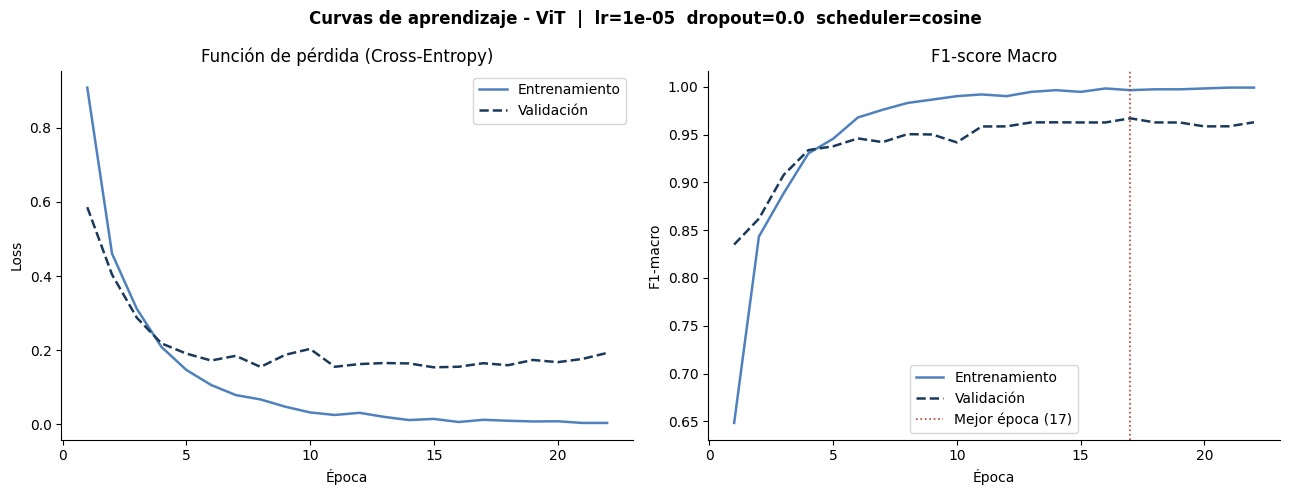

Curvas guardadas en Drive: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/vit_curvas_aprendizaje.png


In [11]:
# Curvas de aprendizaje del mejor ensayo
hist  = mejor_ensayo['historial']
epocas = range(1, len(hist['loss_train']) + 1)

COLOR_TRAIN = '#4f81bd'
COLOR_VAL   = '#1a3a5c'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Curvas de aprendizaje - ViT  |  "
    f"lr={mejor_ensayo['config']['lr']:.0e}  "
    f"dropout={mejor_ensayo['config']['dropout']}  "
    f"scheduler={mejor_ensayo['config']['scheduler']}",
    fontsize=12, fontweight='bold'
)

# Pérdida
axes[0].plot(epocas, hist['loss_train'], color=COLOR_TRAIN, linewidth=1.8, label='Entrenamiento')
axes[0].plot(epocas, hist['loss_val'],   color=COLOR_VAL,   linewidth=1.8, label='Validación', linestyle='--')
axes[0].set_title('Función de pérdida (Cross-Entropy)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# F1-macro
axes[1].plot(epocas, hist['f1_train'], color=COLOR_TRAIN, linewidth=1.8, label='Entrenamiento')
axes[1].plot(epocas, hist['f1_val'],   color=COLOR_VAL,   linewidth=1.8, label='Validación', linestyle='--')
# Marcar mejor época
mejor_ep = hist['f1_val'].index(max(hist['f1_val'])) + 1
axes[1].axvline(mejor_ep, color='#c0392b', linestyle=':', linewidth=1.2,
               label=f'Mejor época ({mejor_ep})')
axes[1].set_title('F1-score Macro')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('F1-macro')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
ruta_curvas = DIR_PROYECTO / 'vit_curvas_aprendizaje.png'
plt.savefig(ruta_curvas, dpi=150, bbox_inches='tight')
plt.show()
print(f"Curvas guardadas en Drive: {ruta_curvas}")


## Evaluación final sobre conjunto de prueba

In [12]:
# Cargar el mejor estado del modelo
modelo_final = construir_modelo(mejor_ensayo['config']['dropout'])
modelo_final.load_state_dict(mejor_ensayo['mejor_estado'])
modelo_final.eval()

loader_test = DataLoader(ds_test, batch_size=16, shuffle=False,
                         num_workers=2, pin_memory=True)

etiq_test, pred_test, prob_test, metricas_test = evaluar(modelo_final, loader_test)

print("=" * 55)
print("  Resultados Finales - Conjunto de Prueba (ViT)")
print("=" * 55)
print(f"  Accuracy global  : {metricas_test['accuracy']:.4f}  ({metricas_test['accuracy']*100:.2f}%)")
print(f"  F1-score macro   : {metricas_test['f1_macro']:.4f}")
print(f"  Precision macro  : {metricas_test['precision']:.4f}")
print(f"  Recall macro     : {metricas_test['recall']:.4f}")
if metricas_test.get('auc_roc'):
    print(f"  AUC-ROC (macro)  : {metricas_test['auc_roc']:.4f}")
print()
print("  F1-score por clase:")
for i, clase in enumerate(CLASES):
    print(f"    {clase:<15} {metricas_test['f1_clases'][i]:.4f}")
print()
print("  Reporte completo:")
print(classification_report(etiq_test, pred_test,
      target_names=CLASES, digits=4))


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Resultados Finales - Conjunto de Prueba (ViT)
  Accuracy global  : 0.9458  (94.58%)
  F1-score macro   : 0.9462
  Precision macro  : 0.9467
  Recall macro     : 0.9458
  AUC-ROC (macro)  : 0.9904

  F1-score por clase:
    glioma          0.9167
    meningioma      0.9016
    notumor         0.9748
    pituitary       0.9916

  Reporte completo:
              precision    recall  f1-score   support

      glioma     0.9167    0.9167    0.9167        60
  meningioma     0.8871    0.9167    0.9016        60
     notumor     0.9831    0.9667    0.9748        60
   pituitary     1.0000    0.9833    0.9916        60

    accuracy                         0.9458       240
   macro avg     0.9467    0.9458    0.9462       240
weighted avg     0.9467    0.9458    0.9462       240



## Matriz de confusión

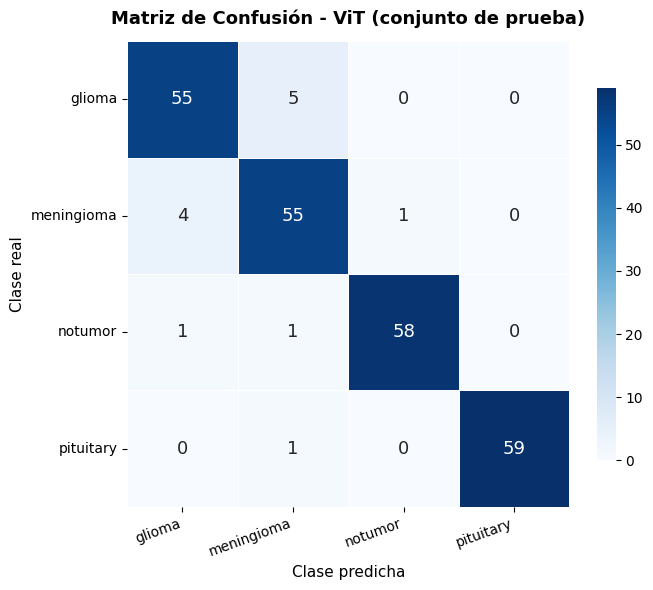

Matriz guardada en Drive: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/vit_matriz_confusion.png


In [13]:
mc = confusion_matrix(etiq_test, pred_test)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    mc, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASES, yticklabels=CLASES,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 13},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Confusión - ViT (conjunto de prueba)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Clase predicha', fontsize=11)
ax.set_ylabel('Clase real', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

ruta_mc = DIR_PROYECTO / 'vit_matriz_confusion.png'
plt.savefig(ruta_mc, dpi=150, bbox_inches='tight')
plt.show()
print(f"Matriz guardada en Drive: {ruta_mc}")


## Mapas de atención

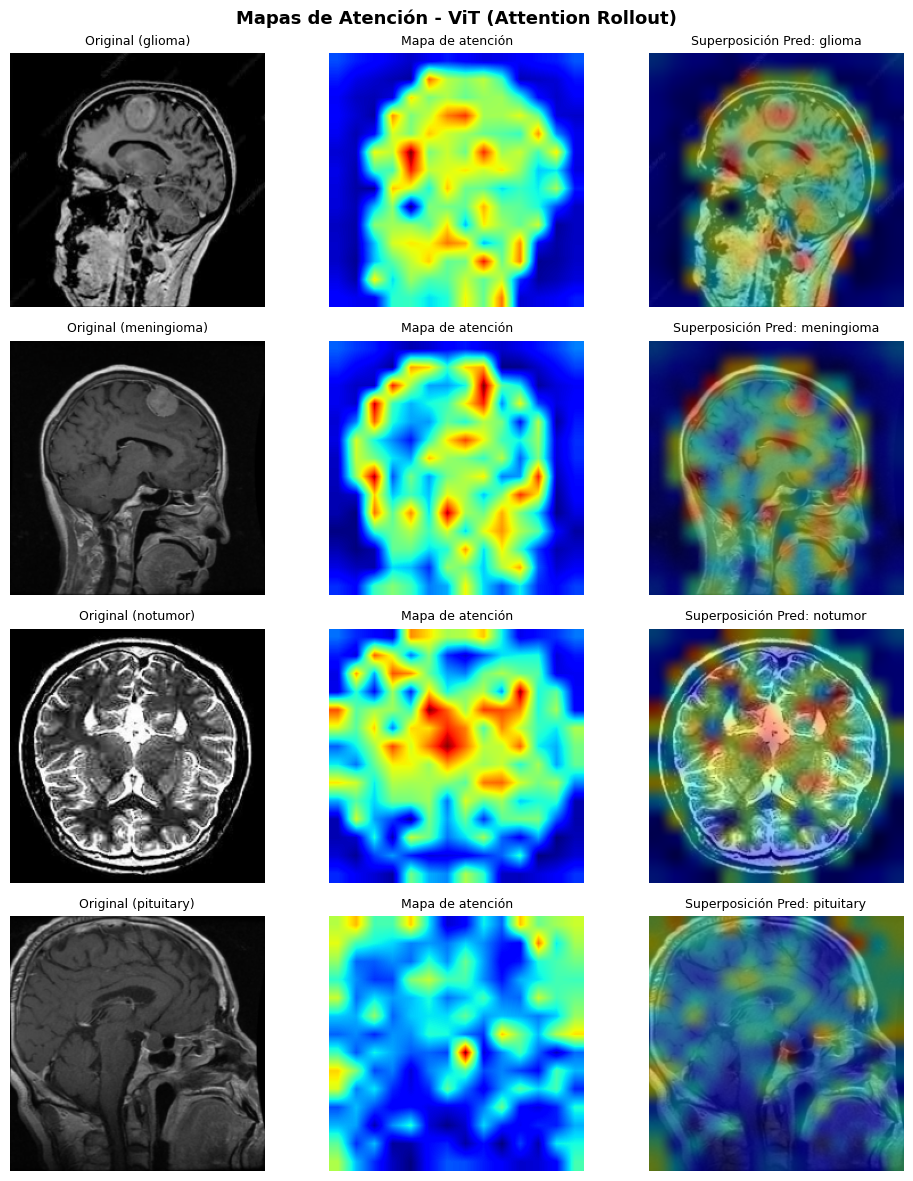

Mapas de atencion guardados en Drive: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/vit_mapas_atencion.png


In [14]:
def obtener_mapa_atencion(modelo, imagen_tensor: torch.Tensor) -> np.ndarray:
    """Calcula el mapa de atencion por Attention Rollout.
    Promedia los pesos de atencion a lo largo de los 12 bloques
    y proyecta sobre la imagen de entrada.
    """
    modelo.eval()
    with torch.no_grad():
        outputs = modelo(
            imagen_tensor.unsqueeze(0).to(DEVICE),
            output_attentions=True
        )
    atenciones = outputs.attentions
    if atenciones is None:
        return None
    n_tokens = atenciones[0].shape[-1]
    rollout = torch.eye(n_tokens).to(DEVICE)

    for att in atenciones:
        att_media = att.mean(dim=1)[0]
        att_media = att_media + torch.eye(n_tokens).to(DEVICE)
        att_media = att_media / att_media.sum(dim=-1, keepdim=True)
        rollout = torch.matmul(att_media, rollout)

    mapa = rollout[0, 1:]
    mapa = mapa.reshape(14, 14).detach().cpu().numpy()
    mapa = (mapa - mapa.min()) / (mapa.max() - mapa.min() + 1e-8)
    return mapa


def desnormalizar(tensor_img: torch.Tensor) -> np.ndarray:
    """Invierte la normalizacion ImageNet para visualizacion."""
    media = torch.tensor(MEDIA).view(3, 1, 1)
    desv  = torch.tensor(DESV).view(3, 1, 1)
    img   = tensor_img * desv + media
    return img.permute(1, 2, 0).clamp(0, 1).numpy()


# Visualizar 1 muestra por clase
fig, axes = plt.subplots(N_CLASES, 3, figsize=(10, N_CLASES * 3))
fig.suptitle('Mapas de Atención - ViT (Attention Rollout)',
             fontsize=13, fontweight='bold')

for fila, clase in enumerate(CLASES):
    # Buscar una muestra correctamente clasificada de esta clase
    indices_clase = [i for i, (_, e) in enumerate(ds_test.muestras)
                     if e == CLASE2IDX[clase]]
    muestra_encontrada = False

    for idx in indices_clase[:30]:
        img_t, etiq = ds_test[idx]
        pred_idx = modelo_final(img_t.unsqueeze(0).to(DEVICE)).logits.argmax(1).item()
        if pred_idx == etiq:
            mapa = obtener_mapa_atencion(modelo_final, img_t)
            if mapa is not None:
                img_np = desnormalizar(img_t)

                # Imagen original
                axes[fila][0].imshow(img_np)
                axes[fila][0].set_title(f'Original ({clase})', fontsize=9)
                axes[fila][0].axis('off')

                # Mapa de atencion
                axes[fila][1].imshow(mapa, cmap='jet', interpolation='bilinear')
                axes[fila][1].set_title('Mapa de atención', fontsize=9)
                axes[fila][1].axis('off')

                # Superposicion
                from PIL import Image as PILImage
                import matplotlib.cm as cm
                mapa_rgb = cm.jet(mapa)[:, :, :3]
                mapa_resized = np.array(
                    PILImage.fromarray((mapa_rgb * 255).astype(np.uint8))
                    .resize((IMG_SIZE, IMG_SIZE))
                ) / 255.0
                overlay = 0.55 * img_np + 0.45 * mapa_resized
                axes[fila][2].imshow(overlay.clip(0, 1))
                axes[fila][2].set_title(f'Superposición Pred: {IDX2CLASE[pred_idx]}', fontsize=9)
                axes[fila][2].axis('off')

                muestra_encontrada = True
                break

    if not muestra_encontrada:
        for col in range(3):
            axes[fila][col].axis('off')
            axes[fila][col].set_title(f'({clase}: sin muestra correcta)', fontsize=8)

plt.tight_layout()
ruta_atencion = DIR_PROYECTO / 'vit_mapas_atencion.png'
plt.savefig(ruta_atencion, dpi=150, bbox_inches='tight')
plt.show()
print(f"Mapas de atencion guardados en Drive: {ruta_atencion}")


## Guardar Checkpoint y resultados en Drive

In [15]:
# Guardar pesos del mejor modelo
DIR_CHECKPOINTS = DIR_PROYECTO / 'checkpoints'
DIR_CHECKPOINTS.mkdir(exist_ok=True)
ruta_checkpoint = DIR_CHECKPOINTS / 'vit_mejor_modelo.pth'
torch.save({
    'model_state_dict': mejor_ensayo['mejor_estado'],
    'config'          : mejor_ensayo['config'],
    'metricas_val'    : {'f1_macro': mejor_ensayo['mejor_f1_val']},
    'clases'          : CLASES,
    'clase2idx'       : CLASE2IDX,
}, ruta_checkpoint)
print(f"Checkpoint guardado: {ruta_checkpoint}")

# Guardar resultados completos en JSON
resultados_json = {
    'modelo'           : 'google/vit-base-patch16-224',
    'mejor_config'     : {k: v for k, v in mejor_ensayo['config'].items() if k != 'id'},
    'mejor_f1_val'     : round(mejor_ensayo['mejor_f1_val'], 6),
    'epocas_entrenadas': len(mejor_ensayo['historial']['loss_train']),
    'tiempo_total_seg' : mejor_ensayo['tiempo_seg'],
    'metricas_test'    : {
        'accuracy'   : round(metricas_test['accuracy'], 6),
        'f1_macro'   : round(metricas_test['f1_macro'], 6),
        'precision'  : round(metricas_test['precision'], 6),
        'recall'     : round(metricas_test['recall'], 6),
        'auc_roc'    : round(metricas_test['auc_roc'], 6) if metricas_test.get('auc_roc') else None,
        'f1_por_clase': {c: round(metricas_test['f1_clases'][i], 6)
                         for i, c in enumerate(CLASES)},
    },
    'historial_mejor_ensayo': mejor_ensayo['historial'],
    'resumen_ensayos': [
        {
            'id'          : r['id'],
            'lr'          : r['config']['lr'],
            'dropout'     : r['config']['dropout'],
            'scheduler'   : r['config']['scheduler'],
            'f1_val'      : round(r['mejor_f1_val'], 6),
            'tiempo_min'  : round(r['tiempo_seg'] / 60, 2),
        }
        for r in resultados_ensayos
    ],
}

ruta_resultados = DIR_PROYECTO / 'vit_resultados.json'
with open(ruta_resultados, 'w', encoding='utf-8') as f:
    json.dump(resultados_json, f, indent=2, ensure_ascii=False)
print(f"Resultados guardados: {ruta_resultados}")


Checkpoint guardado: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/checkpoints/vit_mejor_modelo.pth
Resultados guardados: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/vit_resultados.json


## Resumen

In [16]:
print("=" * 60)
print("  Resumen Fine-Tuning ViT")
print("=" * 60)
print(f"  Modelo        : google/vit-base-patch16-224")
print(f"  Mejor config  : lr={mejor_ensayo['config']['lr']:.0e}"
      f"  dropout={mejor_ensayo['config']['dropout']}"
      f"  scheduler={mejor_ensayo['config']['scheduler']}")
print(f"  Epocas        : {len(mejor_ensayo['historial']['loss_train'])}")
print(f"  Tiempo total  : {mejor_ensayo['tiempo_seg']/60:.1f} min")
print()
print("  Metricas en conjunto de PRUEBA:")
print(f"    Accuracy    : {metricas_test['accuracy']*100:.2f}%")
print(f"    F1-macro    : {metricas_test['f1_macro']:.4f}")
print(f"    Precision   : {metricas_test['precision']:.4f}")
print(f"    Recall      : {metricas_test['recall']:.4f}")
if metricas_test.get('auc_roc'):
    print(f"    AUC-ROC     : {metricas_test['auc_roc']:.4f}")
print()
print("  Archivos generados en Drive:")
for archivo in ['vit_curvas_aprendizaje.png',
                'vit_matriz_confusion.png',
                'vit_mapas_atencion.png',
                'vit_resultados.json',
                'checkpoints/vit_mejor_modelo.pth']:
    print(f"    {archivo}")


  Resumen Fine-Tuning ViT
  Modelo        : google/vit-base-patch16-224
  Mejor config  : lr=1e-05  dropout=0.0  scheduler=cosine
  Epocas        : 22
  Tiempo total  : 17.2 min

  Metricas en conjunto de PRUEBA:
    Accuracy    : 94.58%
    F1-macro    : 0.9462
    Precision   : 0.9467
    Recall      : 0.9458
    AUC-ROC     : 0.9904

  Archivos generados en Drive:
    vit_curvas_aprendizaje.png
    vit_matriz_confusion.png
    vit_mapas_atencion.png
    vit_resultados.json
    checkpoints/vit_mejor_modelo.pth
